# 3C - Precursores: o que antecede o pico do Nino 3.4?

**Pergunta especifica.** Quais variaveis fisicas lideram a SSTA do Nino 3.4 e em que defasagem semanal?

**Objetivo.** Construir um ranking preliminar de precursores para o aquecimento maximo, antes dos filtros estatisticos do 3D/3E.

**Justificativa.** O usuario precisa saber quais variaveis explicam o aquecimento maximo de forma antecipada. Esta etapa mostra o sinal bruto e sua defasagem, mas ainda nao e previsao operacional.

**Metodologia.** Correlacao entre cada variavel semanal e SSTA Nino 3.4 futura. Lag positivo significa que a variavel antecede a SSTA alvo. A matriz publica nao inclui metricas auxiliares acumuladas; usa apenas SSTA, recarga/subsuperficie, SSH/tilt e vento.

**Saidas.** `phase3C_lagcorr.csv`, `phase3C_ranking_lags.csv`, `3C1_heatmap_lags.png`, `3C2_mapa_lon_lag.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
tgt=w['nino34_ssta']; COMMON='1993-01-01'; LAGS=range(0,79)
preds=[c for c in w.columns if c!='nino34_ssta']
def lcf(df,tg,lags): return pd.DataFrame({c:{lag:tg.corr(df[c].shift(lag)) for lag in lags} for c in df.columns})
lc=lcf(w.loc[COMMON:,preds],tgt.loc[COMMON:],LAGS)
lc.rename_axis('lag_semanas').to_csv(u.STATS/'phase3C_lag_correlacoes.csv')
print('Correlacoes defasadas (1993+) calculadas para:',list(lc.columns))

Correlacoes defasadas (1993+) calculadas para: ['d20_m', 'tilt_m', 'tilt_slope', 'ohc_0_100', 'ohc_0_300', 'ohc_0_700', 'ohc_300_700', 'ssh_m', 'wwv', 't50m', 't100m', 't150m', 't200m', 't300m', 't500m', 't700m', 'tau_x_anom_nino34_pa', 'u10_anom', 'v10_anom', 'mslp_anom', 'tcwv_anom', 'slhf_anom', 'sshf_anom', 'ssr_anom', 'str_anom', 'u850_anom', 'u200_anom', 'omega850_anom', 'omega500_anom', 'div850_anom']


In [2]:
rank = pd.DataFrame({'r_max_abs': lc.abs().max(), 'lag_do_max_semanas': lc.abs().idxmax()})
rank['r_no_lag_max'] = [round(lc.loc[l, v], 3) for v, l in zip(rank.index, rank['lag_do_max_semanas'])]
rank['sinal'] = np.where(rank['r_no_lag_max'] >= 0, 'positivo', 'negativo')
rank['leitura'] = rank.apply(lambda r: f"{u.var_label(r.name, short=True)} antecede SSTA em {int(r['lag_do_max_semanas'])} semanas (r={r['r_no_lag_max']:+.2f})", axis=1)
rank = rank.sort_values('r_max_abs', ascending=False)
u.save_table(rank, 'phase3C_ranking_lags.csv')
print('Ranking bruto por maior |r| (antes de N_eff/FDR):')
print(rank[['r_max_abs','lag_do_max_semanas','r_no_lag_max','leitura']].to_string())


[tabela] data/processed/parquet/statistics/phase3C_ranking_lags.csv
Ranking bruto por maior |r| (antes de N_eff/FDR):
                      r_max_abs  lag_do_max_semanas  r_no_lag_max                                             leitura
ohc_0_100              0.901127                   1         0.901      ohc_0_100 antecede SSTA em 1 semanas (r=+0.90)
t50m                   0.887089                   0         0.887           t50m antecede SSTA em 0 semanas (r=+0.89)
tilt_m                 0.771618                   0         0.772           Tilt antecede SSTA em 0 semanas (r=+0.77)
ssh_m                  0.755088                   6         0.755            SSH antecede SSTA em 6 semanas (r=+0.76)
tcwv_anom              0.754368                   0         0.754      tcwv_anom antecede SSTA em 0 semanas (r=+0.75)
tilt_slope             0.743599                   0         0.744     tilt_slope antecede SSTA em 0 semanas (r=+0.74)
ohc_0_300              0.737875                   6     

[figura] data/processed/figures/fase3/3C1_heatmap_lags.png


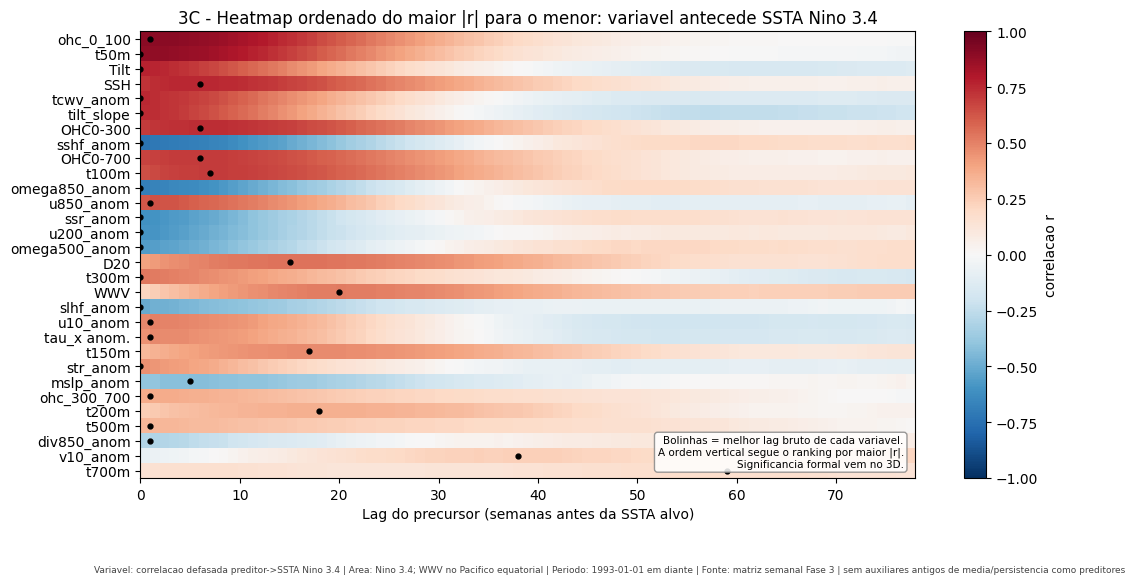

In [3]:
fig, ax = plt.subplots(figsize=(12.5, 5.8))
cols = rank.index.tolist()
mat = lc[cols].T.values
im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1, extent=[min(LAGS), max(LAGS), len(cols)-0.5, -0.5])
ax.set_yticks(range(len(cols)))
ax.set_yticklabels([u.var_label(c, short=True) for c in cols])
ax.set_xlabel('Lag do precursor (semanas antes da SSTA alvo)')
ax.set_title('3C - Heatmap ordenado do maior |r| para o menor: variavel antecede SSTA Nino 3.4')
fig.colorbar(im, ax=ax, label='correlacao r')
for y, c in enumerate(cols):
    lag = int(rank.loc[c, 'lag_do_max_semanas'])
    ax.plot(lag, y, 'ko', ms=3.5)
u.add_note(ax, 'Bolinhas = melhor lag bruto de cada variavel.\nA ordem vertical segue o ranking por maior |r|.\nSignificancia formal vem no 3D.', loc='lower right')
u.stamp_caption(fig, variavel='correlacao defasada preditor->SSTA Nino 3.4', area='Nino 3.4; WWV no Pacifico equatorial', periodo=f'{COMMON} em diante', fonte='matriz semanal Fase 3', extra='sem auxiliares antigos de media/persistencia como preditores')
u.save_fig(fig, '3C1_heatmap_lags.png')
plt.show()


[figura] data/processed/figures/fase3/3C2_mapa_lon_lag.png


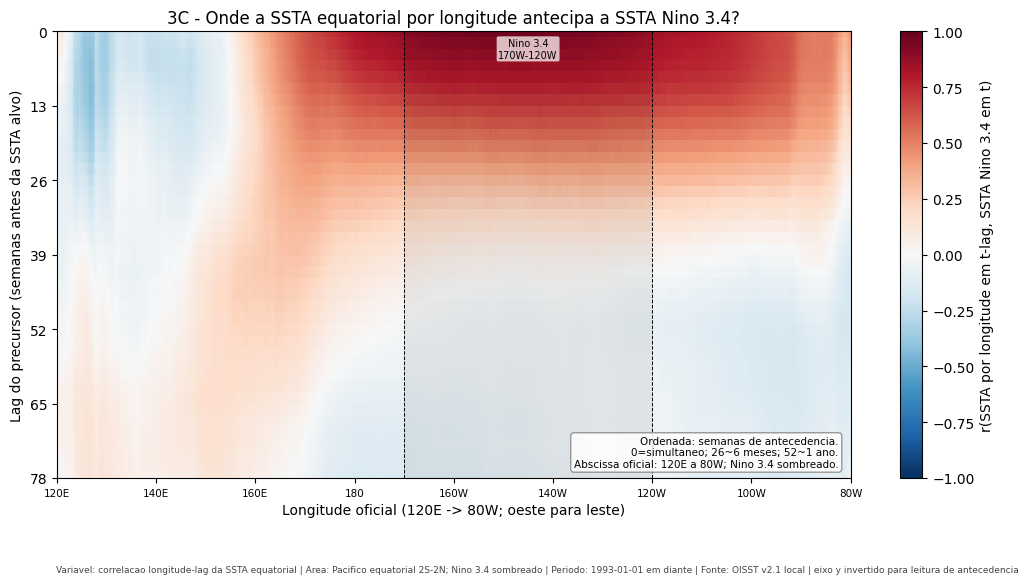

In [4]:
eq = u.load_eqband_weekly().loc[COMMON:]
t = tgt.loc[COMMON:]
eqa, ta = eq.align(t, join='inner', axis=0)
tv = ta.values
lags = list(range(0, 79, 2))
ll = np.full((len(lags), eqa.shape[1]), np.nan)
for i, l in enumerate(lags):
    if l == 0:
        X, y = eqa.values, tv
    else:
        X, y = eqa.iloc[:-l].values, tv[l:]
    ym = y - np.nanmean(y)
    for j in range(X.shape[1]):
        x = X[:, j]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() > 30:
            xx = x[m] - np.nanmean(x[m])
            yy = ym[m]
            den = np.sqrt(np.sum(xx**2) * np.sum(yy**2))
            ll[i, j] = np.sum(xx*yy)/den if den else np.nan
lon = eqa.columns.values.astype(float)
fig, ax = plt.subplots(figsize=(12.8, 5.8))
pc = ax.pcolormesh(lon, lags, ll, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
u.add_nino34_lon_band(ax)
u.format_lon_axis(ax)
u.format_lag_axis(ax, max_lag=max(lags))
ax.set_title('3C - Onde a SSTA equatorial por longitude antecipa a SSTA Nino 3.4?')
fig.colorbar(pc, ax=ax, label='r(SSTA por longitude em t-lag, SSTA Nino 3.4 em t)')
u.add_note(ax, 'Ordenada: semanas de antecedencia.\n0=simultaneo; 26~6 meses; 52~1 ano.\nAbscissa oficial: 120E a 80W; Nino 3.4 sombreado.', loc='lower right')
u.stamp_caption(fig, variavel='correlacao longitude-lag da SSTA equatorial', area='Pacifico equatorial 2S-2N; Nino 3.4 sombreado', periodo=f'{COMMON} em diante', fonte='OISST v2.1 local', extra='eixo y invertido para leitura de antecedencia')
u.save_fig(fig, '3C2_mapa_lon_lag.png')
plt.show()


**Leitura do 3C.** O ranking preliminar (ver saida numerica) e liderado pelo bloco de recarga - **tilt (lag 0), SSH/OHC (~6 sem), D20 (~15 sem), WWV (~20 sem)** - todos series do Nino 3.4 exceto WWV (Pac. equatorial). O mapa lon x lag mostra a inclinacao oeste->leste: anomalias no Pacifico central-oeste antecedem a caixa Nino 3.4, coerente com Kelvin/adveccao. **Nada aqui e significancia** - isso e 3D.